# Model comparison

Compare the baselines and candidate models on `model_dataset` at the 5, 10 and 15 minute horizons.
Every model goes through the same time-based folds, so the results can be compared directly.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# The notebook may be launched from either the repo root or notebooks/, so put the repo root on the path.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.modeling.train import build_xy, regression_metrics, select_feature_columns
from src.processing.targets import DEFAULT_HORIZONS_MINUTES
from src.storage.db import get_engine, read_table

pd.set_option("display.width", 200)

## Load the dataset

Reads `model_dataset` from the configured database (Postgres by default, or whatever `DATABASE_URL` points at).

In [2]:
engine = get_engine()
df = read_table(engine, "model_dataset")
engine.dispose()

df["window_start"] = pd.to_datetime(df["window_start"], utc=True)
df = df.sort_values("window_start").reset_index(drop=True)
FEATURES = select_feature_columns(df)
HORIZONS = DEFAULT_HORIZONS_MINUTES

print(f"{len(df)} rows, {df['trip_id'].nunique()} trains, {len(FEATURES)} features")
print(f"from {df['window_start'].min()} to {df['window_start'].max()}")
pd.Series({h: int(df[f"target_delay_{h}min"].notna().sum()) for h in HORIZONS}, name="labelled_rows")

197966 rows, 2158 trains, 36 features
from 2026-09-09 05:00:00+00:00 to 2026-09-23 00:07:00+00:00


5     184202
10    172264
15    160396
Name: labelled_rows, dtype: int64

## Remove impossible delays

A few rows report delays of several hours, which is a feed error rather than a real train. Anything beyond one hour either way is dropped.

In [3]:
MAX_ABS_DELAY = 3600
delay_cols = ["arrival_delay"] + [f"target_delay_{h}min" for h in HORIZONS]
# Missing targets are fine here, only values that are present and impossible get dropped.
bad = (df[delay_cols].abs() > MAX_ABS_DELAY).any(axis=1)
print(f"dropping {int(bad.sum())} of {len(df)} rows")
df = df[~bad].reset_index(drop=True)

dropping 15 of 197966 rows


## Collection runs covered

Each separate collection run is a different slice of conditions, so it is worth knowing how many we have before trusting any result.

In [4]:
# A gap of more than 30 minutes between windows marks the start of a new run.
run_id = (df["window_start"].diff() > pd.Timedelta(minutes=30)).cumsum()
runs = df.groupby(run_id).agg(
    start=("window_start", "min"),
    end=("window_start", "max"),
    rows=("trip_id", "size"),
    trains=("trip_id", "nunique"),
    peak_share=("is_peak", "mean"),
    weekend_share=("is_weekend", "mean"),
)
runs

,start,end,rows,trains,peak_share,weekend_share
window_start,,,,,,
0,2026-09-09 05:00:00+00:00,2026-09-09 12:32:00+00:00,13573,188,0.570765,0.000000
1,2026-09-09 13:17:00+00:00,2026-09-09 16:56:00+00:00,2067,24,0.000000,0.000000
2,2026-09-09 18:10:00+00:00,2026-09-11 16:53:00+00:00,78292,916,0.317376,0.025801
3,2026-09-11 18:08:00+00:00,2026-09-12 17:03:00+00:00,39159,464,0.000000,1.000000
4,2026-09-13 18:10:00+00:00,2026-09-14 16:23:00+00:00,41549,505,0.328046,0.000000
5,2026-09-14 18:10:00+00:00,2026-09-15 05:23:00+00:00,20728,263,0.223707,0.000000
6,2026-09-15 06:48:00+00:00,2026-09-15 07:46:00+00:00,2523,70,1.000000,0.000000
7,2026-09-20 00:07:00+00:00,2026-09-20 00:07:00+00:00,20,20,0.000000,1.000000
8,2026-09-23 00:07:00+00:00,2026-09-23 00:07:00+00:00,40,40,0.000000,0.000000


## Time-based folds

Rolling-origin folds: each fold trains on everything before a cut-off and tests on the block right after it.
Training rows close to the cut-off are dropped, because their targets would look into the test block.

In [5]:
N_FOLDS = 4
MIN_TRAIN, MIN_TEST = 50, 10  # folds smaller than this are skipped


def time_folds(data, n_folds=N_FOLDS):
    # Cut on unique timestamps so one minute never lands on both sides of a split.
    times = np.sort(data["window_start"].unique())
    edges = [times[int(len(times) * k / (n_folds + 1))] for k in range(1, n_folds + 1)] + [None]
    for k in range(n_folds):
        test_start, test_end = edges[k], edges[k + 1]
        test_mask = data["window_start"] >= test_start
        if test_end is not None:
            test_mask &= data["window_start"] < test_end
        yield k, data["window_start"] < test_start, test_mask


def train_test_for_fold(train_mask, test_mask, horizon):
    test_start = df.loc[test_mask, "window_start"].min()
    # Keep only training rows whose target is observed before the test block starts.
    safe_train = train_mask & (df["window_start"] + pd.Timedelta(minutes=horizon) < test_start)
    x_train, y_train = build_xy(df[safe_train], horizon, FEATURES)
    x_test, y_test = build_xy(df[test_mask], horizon, FEATURES)
    return x_train, y_train, x_test, y_test


def latest_usable_fold(horizon):
    # The newest folds often have no long-horizon labels yet, so walk back to one that does.
    for k, train_mask, test_mask in reversed(list(time_folds(df))):
        x_train, y_train, x_test, y_test = train_test_for_fold(train_mask, test_mask, horizon)
        if len(x_train) >= MIN_TRAIN and len(x_test) >= MIN_TEST:
            return k, x_train, y_train, x_test, y_test
    return None


pd.DataFrame([
    {"fold": k, "train_rows": int(tr.sum()), "test_rows": int(te.sum()),
     "test_from": df.loc[te, "window_start"].min(), "test_to": df.loc[te, "window_start"].max()}
    for k, tr, te in time_folds(df)
])

,fold,train_rows,test_rows,test_from,test_to
0,0,38628,37597,2026-09-10 06:19:00+00:00,2026-09-11 05:25:00+00:00
1,1,76225,38942,2026-09-11 05:26:00+00:00,2026-09-12 05:36:00+00:00
2,2,115167,42453,2026-09-12 05:37:00+00:00,2026-09-14 05:40:00+00:00
3,3,157620,40331,2026-09-14 05:41:00+00:00,2026-09-23 00:07:00+00:00


## Models

Two baselines and four candidates, each trained two ways: on the delay itself, and on the change in delay from now.
The change version starts from persistence and only learns the correction. `hgb_change_abs` also trains on absolute error, so it aims at the typical change (usually zero) instead of being pulled by rare big jumps.

In [6]:
class Persistence:
    # Predicts that the delay later equals the delay now.
    def fit(self, X, y):
        return self

    def predict(self, X):
        return X["arrival_delay"].to_numpy()


class MeanDelay:
    # Predicts the average training delay for every row.
    def fit(self, X, y):
        self.mean_ = float(y.mean())
        return self

    def predict(self, X):
        return np.full(len(X), self.mean_)


class PredictChange:
    # Trains the wrapped model on how much the delay will change, then adds that back onto the current delay.
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        self.model.fit(X, y - X["arrival_delay"])
        return self

    def predict(self, X):
        return X["arrival_delay"].to_numpy() + self.model.predict(X)


MODELS = {
    "persistence": lambda: Persistence(),
    "mean_delay": lambda: MeanDelay(),
    # Ridge cannot handle missing lags, so fill them with the median first.
    "ridge": lambda: make_pipeline(SimpleImputer(strategy="median", keep_empty_features=True), StandardScaler(), Ridge(alpha=1.0)),
    # n_jobs=4 leaves cores free so the laptop stays usable while it trains.
    "random_forest": lambda: RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_leaf=5, n_jobs=4, random_state=42),
    "hgb": lambda: HistGradientBoostingRegressor(random_state=42),
    # Slower learning and bigger leaves, to see if the default overfits our small dataset.
    "hgb_tuned": lambda: HistGradientBoostingRegressor(learning_rate=0.05, max_iter=300, min_samples_leaf=40, random_state=42),
}

for name in ["ridge", "random_forest", "hgb"]:
    MODELS[f"{name}_change"] = lambda name=name: PredictChange(MODELS[name]())

# Same as hgb_change, but trained on absolute error to match how we score it.
MODELS["hgb_change_abs"] = lambda: PredictChange(HistGradientBoostingRegressor(loss="absolute_error", random_state=42))


## Run every model on every fold

In [7]:
rows = []
for horizon in HORIZONS:
    for k, train_mask, test_mask in time_folds(df):
        x_train, y_train, x_test, y_test = train_test_for_fold(train_mask, test_mask, horizon)
        if len(x_train) < MIN_TRAIN or len(x_test) < MIN_TEST:
            continue  # too few labelled rows in this fold to say anything
        for name, build in MODELS.items():
            model = build().fit(x_train, y_train)
            metrics = regression_metrics(y_test, model.predict(x_test))
            rows.append({"horizon": horizon, "fold": k, "model": name, "n_train": len(x_train), "n_test": len(x_test), **metrics})

results = pd.DataFrame(rows)
results.groupby(["horizon", "fold"])[["n_train", "n_test"]].first()

n_train  n_test
horizon fold                 
5       0       35796   35076
        1       70877   36416
        2      107290   39529
        3      146815   37174
10      0       33386   32887
        1       66285   34148
        2      100426   36965
        3      137385   34492
15      0       31007   30715
        1       61739   31882
        2       93613   34406
        3      128003   31852

## Results

Mean and spread across folds. A small spread means the ranking is stable; a large one means we need more data before picking a winner.

In [8]:
summary = results.groupby(["horizon", "model"])[["mae", "rmse", "r2"]].agg(["mean", "std"]).round(2)
summary

mae          rmse           r2      
                               mean    std   mean    std  mean   std
horizon model                                                       
5       hgb                   15.65   1.98  42.01  14.37  0.72  0.09
        hgb_change             8.95   1.90  21.53   4.25  0.91  0.06
        hgb_change_abs         5.82   0.80  15.05   5.13  0.96  0.01
        hgb_tuned             13.57   0.89  38.50  16.21  0.77  0.10
        mean_delay            43.11  14.23  81.95  17.32 -0.08  0.09
        persistence            6.09   1.00  15.68   5.10  0.96  0.01
        random_forest         10.18   1.28  27.42  13.55  0.87  0.08
        random_forest_change   7.85   0.89  18.76   4.05  0.94  0.03
        ridge                 14.32  11.80  28.66  23.23  0.73  0.46
        ridge_change          14.31  11.80  28.65  23.22  0.73  0.46
10      hgb                   17.27   0.95  46.20  15.56  0.68  0.07
        hgb_change            15.91   5.48  41.34  14.39  0.61  0.34
        hgb_change_abs         8.79   1.68  21.57   8.47  0.93  0.02
        hgb_tuned             19.47   1.72  50.61  12.36  0.60  0.05
        mean_delay            43.84  13.89  83.28  18.66 -0.08  0.09
        persistence           10.13   1.86  22.44   7.85  0.92  0.02
        random_forest         14.62   2.20  38.05  12.24  0.75  0.15
        random_forest_change  14.65   5.67  35.90  12.99  0.73  0.29
        ridge                 16.02   4.65  29.70   9.29  0.83  0.15
        ridge_change          16.01   4.65  29.69   9.28  0.83  0.15
15      hgb                   23.58   7.17  58.86  18.50  0.38  0.51
        hgb_change            17.67   3.71  44.68   9.41  0.62  0.27
        hgb_change_abs        11.74   2.09  27.60  12.35  0.89  0.04
        hgb_tuned             27.25   7.60  65.63  12.31  0.22  0.50
        mean_delay            44.52  13.65  84.73  20.21 -0.09  0.10
        persistence           13.50   2.78  28.31  11.22  0.88  0.03
        random_forest         20.95   7.20  49.12  20.02  0.52  0.51
        random_forest_change  16.72   3.92  38.68  12.54  0.72  0.25
        ridge                 22.73  12.77  44.24  26.33  0.52  0.70
        ridge_change          22.74  12.77  44.25  26.34  0.52  0.70

In [9]:
mae_table = results.pivot_table(index="model", columns="horizon", values="mae", aggfunc="mean").round(2)
mae_table.sort_values(HORIZONS[-1])

horizon,5,10,15
model,,,
hgb_change_abs,5.82,8.79,11.74
persistence,6.09,10.13,13.50
random_forest_change,7.85,14.65,16.72
hgb_change,8.95,15.91,17.67
random_forest,10.18,14.62,20.95
ridge,14.32,16.02,22.73
ridge_change,14.31,16.01,22.74
hgb,15.65,17.27,23.58
hgb_tuned,13.57,19.47,27.25


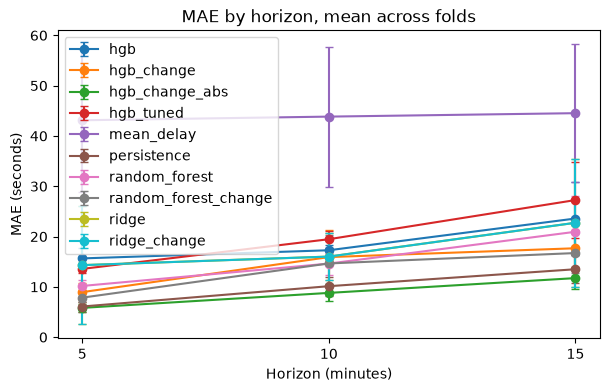

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, part in results.groupby("model"):
    stats = part.groupby("horizon")["mae"].agg(["mean", "std"])
    ax.errorbar(stats.index, stats["mean"], yerr=stats["std"], marker="o", capsize=3, label=name)
ax.set_xlabel("Horizon (minutes)")
ax.set_ylabel("MAE (seconds)")
ax.set_xticks(list(HORIZONS))
ax.set_title("MAE by horizon, mean across folds")
ax.legend()
plt.show()

## Gain over persistence

How much each model cuts the error compared with just repeating the current delay. Above zero means better than the baseline.

In [11]:
base = results[results["model"] == "persistence"].set_index(["horizon", "fold"])["mae"]
gain = results[results["model"] != "persistence"].copy()
gain["gain_vs_persistence"] = 1 - gain["mae"] / gain.set_index(["horizon", "fold"]).index.map(base)
gain.pivot_table(index="model", columns="horizon", values="gain_vs_persistence", aggfunc="mean").round(3)

horizon,5,10,15
model,,,
hgb,-1.660,-0.749,-0.920
hgb_change,-0.528,-0.622,-0.351
hgb_change_abs,0.039,0.131,0.124
hgb_tuned,-1.274,-0.969,-1.205
mean_delay,-6.064,-3.330,-2.323
random_forest,-0.737,-0.527,-0.722
random_forest_change,-0.332,-0.582,-0.340
ridge,-1.694,-0.707,-0.941
ridge_change,-1.693,-0.707,-0.941


## What the models rely on

Permutation importance on the latest fold with enough labelled rows: how much the error grows when one feature is shuffled.
This shows why a model wins or loses at each horizon.

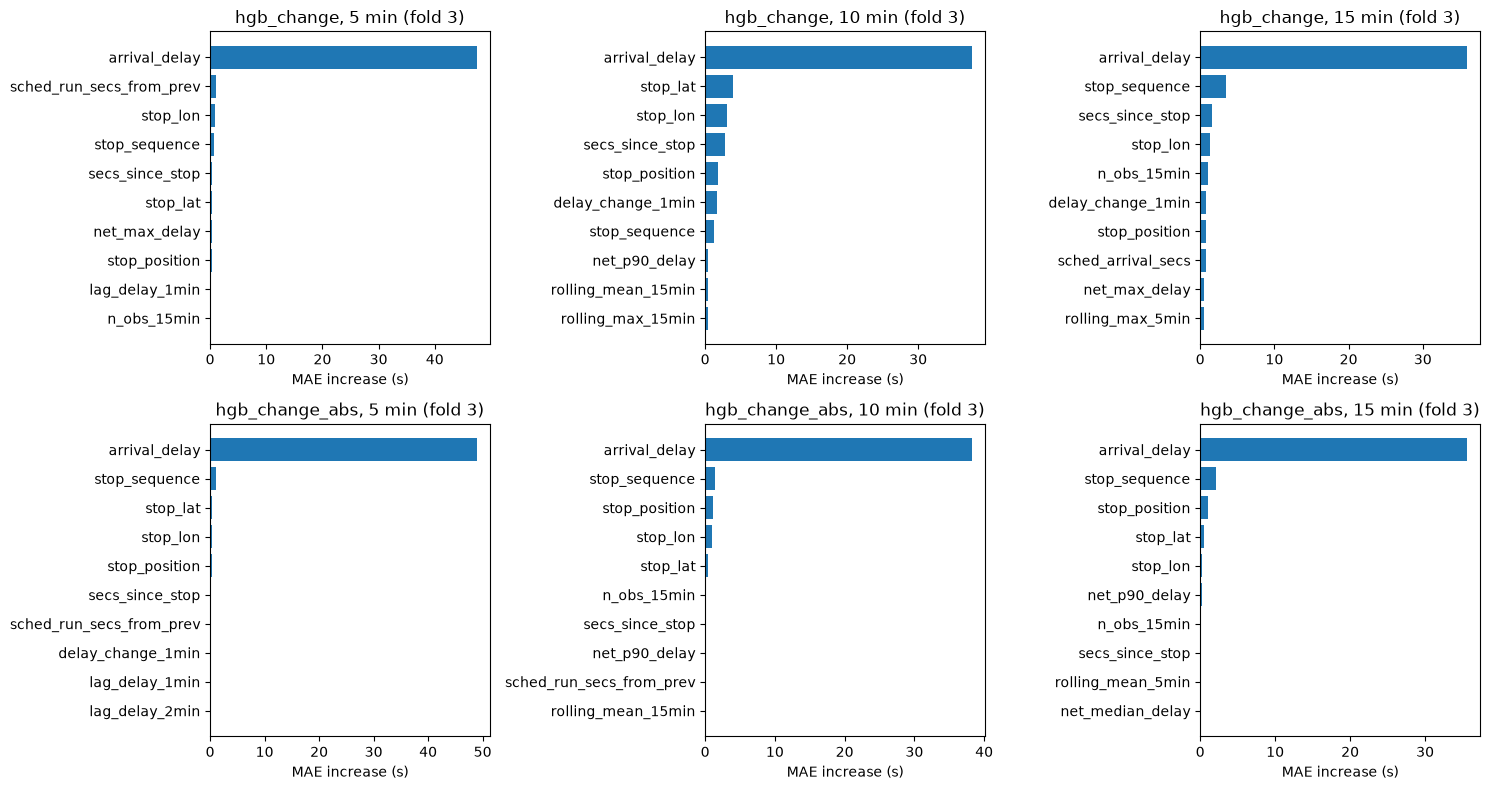

In [12]:
TOP_N = 10
EXPLAIN = ["hgb_change", "hgb_change_abs"]
IMPORTANCE_SAMPLE = 5000  # shuffling features on the full test set is slow, a sample is enough

fig, axes = plt.subplots(len(EXPLAIN), len(HORIZONS), figsize=(15, 4 * len(EXPLAIN)), squeeze=False)
for i, name in enumerate(EXPLAIN):
    for j, horizon in enumerate(HORIZONS):
        ax = axes[i][j]
        fold = latest_usable_fold(horizon)
        if fold is None:
            ax.set_title(f"{name}, {horizon} min: not enough rows")
            continue
        k, x_train, y_train, x_test, y_test = fold
        model = MODELS[name]().fit(x_train, y_train)
        sample = x_test.sample(min(IMPORTANCE_SAMPLE, len(x_test)), random_state=42)
        imp = permutation_importance(model, sample, y_test.loc[sample.index], scoring="neg_mean_absolute_error", n_repeats=10, random_state=42)
        top = pd.Series(imp.importances_mean, index=x_test.columns).nlargest(TOP_N).sort_values()
        ax.barh(top.index, top.values)
        ax.set_title(f"{name}, {horizon} min (fold {k})")
        ax.set_xlabel("MAE increase (s)")
plt.tight_layout()
plt.show()

## Where the errors are

Errors on the latest usable fold for the chosen model, split by conditions. The peak and weekend splits only become useful once we have runs covering them.

In [13]:
CHOSEN = "hgb_change_abs"

parts = []
for horizon in HORIZONS:
    fold = latest_usable_fold(horizon)
    if fold is None:
        continue
    k, x_train, y_train, x_test, y_test = fold
    pred = MODELS[CHOSEN]().fit(x_train, y_train).predict(x_test)
    parts.append(pd.DataFrame({"horizon": horizon, "actual": y_test, "predicted": pred, "abs_error": np.abs(y_test - pred),
                               "is_peak": df.loc[x_test.index, "is_peak"], "is_weekend": df.loc[x_test.index, "is_weekend"]}))
errors = pd.concat(parts)

errors.groupby(["horizon", "is_peak", "is_weekend"])["abs_error"].agg(["mean", "size"]).round(2)

mean   size
horizon is_peak is_weekend              
5       False   False        6.65  23415
        True    False        4.29  13759
10      False   False       11.29  21727
        True    False        4.89  12765
15      False   False       15.73  20074
        True    False        5.46  11778

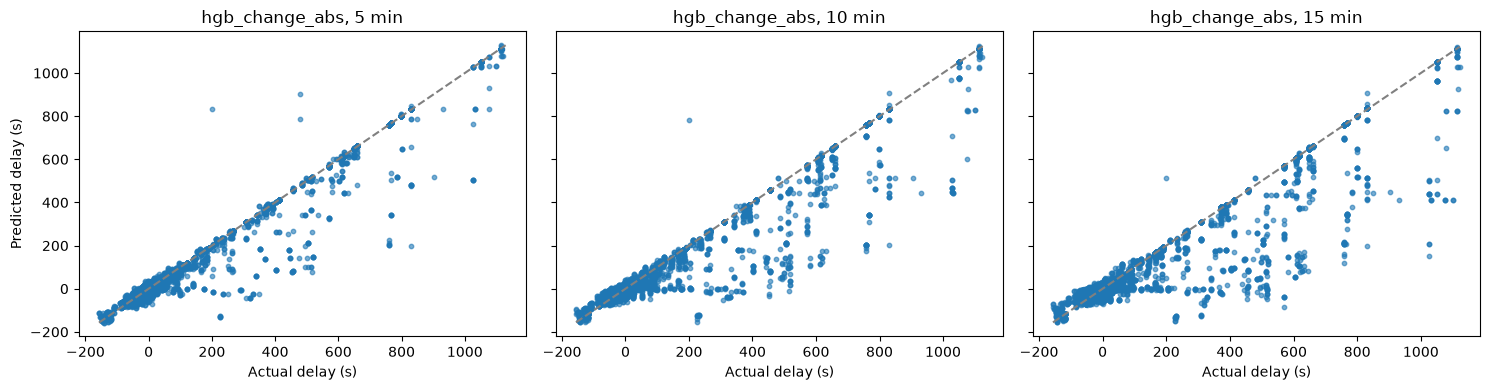

In [14]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(15, 4), sharey=True)
for ax, (horizon, part) in zip(axes, errors.groupby("horizon")):
    ax.scatter(part["actual"], part["predicted"], s=10, alpha=0.6)
    lims = [part[["actual", "predicted"]].min().min(), part[["actual", "predicted"]].max().max()]
    ax.plot(lims, lims, linestyle="--", color="grey")  # perfect predictions sit on this line
    ax.set_title(f"{CHOSEN}, {horizon} min")
    ax.set_xlabel("Actual delay (s)")
axes[0].set_ylabel("Predicted delay (s)")
plt.tight_layout()
plt.show()

## Findings

Run on 2 October 2026: 197,951 rows from 2,158 trains, collected 9 to 15 September (weekdays with both peaks, plus a Saturday).

- **Best model:** `hgb_change_abs` at every horizon. It cuts MAE against persistence by about 4% at 5 minutes and 12 to 13% at 10 and 15 minutes, and wins in every fold at 10 and 15 minutes.
- **Persistence is a strong baseline.** Half the time a train's delay does not change at all over 5 minutes, so "same as now" is hard to beat.
- **Predicting the delay itself fails for trees.** Trees can only output steps, so copying the current delay costs them accuracy everywhere. RandomForest copes better than HGB because its trees are deeper.
- **Predicting the change helps, but only with the right loss.** With squared error the change models chase rare big jumps (like the 14 September disruption) and end up worse than persistence. Absolute error fixes this.
- **Ridge** gains nothing from the change target, as expected for a linear model that already sees the current delay.
- **Features used:** the current delay matters most by far, then position in the trip and stop location. The other features add very little.
- **Errors are higher off-peak** (about 7 s at 5 minutes and 16 s at 15 minutes) than in the peaks (about 4 to 5 s), because the late-night and disruption periods fall off-peak.
- **Change needed in `src/modeling/train.py`:** switch the default to the change target with absolute error loss.
- **Still to do:** more weeks of data (especially disrupted days), and building the dataset day by day so it does not load all trip updates into memory.